
--- Recording Record 1 ---
Speak now for 3 seconds...
Done recording.


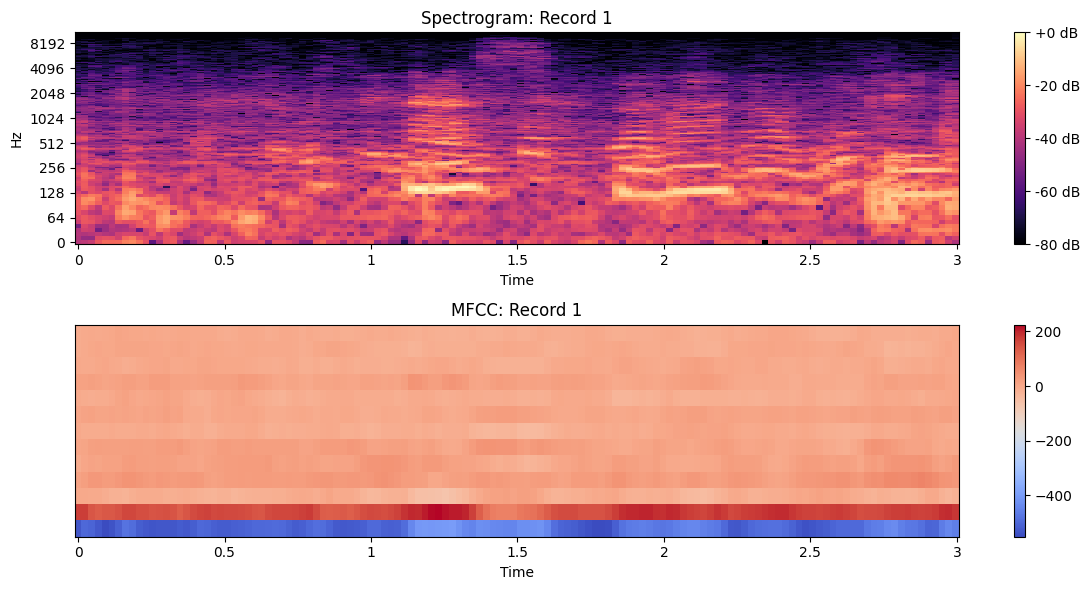


--- Recording Record 2 ---
Speak now for 3 seconds...
Done recording.


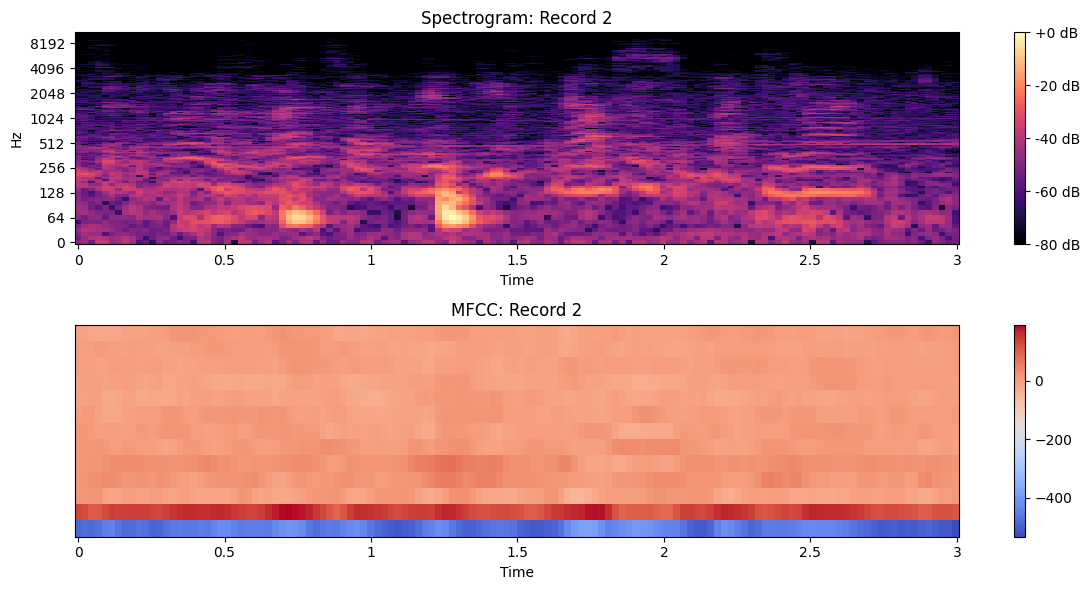

In [1]:
import sounddevice as sd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

def record_and_process(label, fs=22050, duration=3):
    print(f"\n--- Recording {label} ---")
    print(f"Speak now for {duration} seconds...")
    
    # Record audio directly into a numpy array
    recording = sd.rec(int(duration * fs), samplerate=fs, channels=1)
    sd.wait()  # Wait until recording is finished
    print("Done recording.")
    
    # sounddevice returns a 2D array [samples, channels], librosa wants 1D
    y = recording.flatten()
    
    # Calculate Features
    D = np.abs(librosa.stft(y))
    mfcc = librosa.feature.mfcc(y=y, sr=fs, n_mfcc=13)
    
    # Visualization
    plt.figure(figsize=(12, 6))
    
    # Spectrogram
    plt.subplot(2, 1, 1)
    librosa.display.specshow(librosa.amplitude_to_db(D, ref=np.max), 
                             y_axis='log', x_axis='time', sr=fs)
    plt.title(f'Spectrogram: {label}')
    plt.colorbar(format='%+2.0f dB')
    
    # MFCC
    plt.subplot(2, 1, 2)
    librosa.display.specshow(mfcc, x_axis='time', sr=fs)
    plt.title(f'MFCC: {label}')
    plt.colorbar()
    
    plt.tight_layout()
    plt.show()

# Execute for two different voices
record_and_process("Record 1")
record_and_process("Record 2")
